In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


2025-06-20 19:15:34.162713: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750446934.422131      13 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750446934.502008      13 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/asldatasetgru/SignSpeakDataset.csv')

feature_columns = df.columns.drop('word')
df[feature_columns] = df[feature_columns].fillna(0)

print("Dataset Head (after fixing NaNs):")
print(df.head())

print("\nTotal NaN values remaining:", df.isnull().sum().sum())
print("\nNumber of unique signs:", df['word'].nunique())


Dataset Head (after fixing NaNs):
                        _id word  hand[0][0]  hand[0][1]  hand[0][2]  \
0  6601f2a1108f932c23d100d7    a        1023         126          59   
1  6601f2a5108f932c23d100d8    a         778         115          62   
2  6601f2ab108f932c23d100d9    a        1023         136          93   
3  6601f2ae108f932c23d100da    a        1023         175         111   
4  6601f2b0108f932c23d100db    a        1022         315         432   

   hand[0][3]  hand[0][4]  hand[1][0]  hand[1][1]  hand[1][2]  ...  \
0          24          90        1023         116          54  ...   
1          24          42         777          99          67  ...   
2          27          30        1023         128          86  ...   
3          44          70        1023         126          71  ...   
4         108         374        1023         229         178  ...   

   hand[77][0]  hand[77][1]  hand[77][2]  hand[77][3]  hand[77][4]  \
0          0.0          0.0          0.0  

In [3]:
feature_columns = df.columns[1:] 
X = df[feature_columns].values
y = df['word'].values


In [4]:
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

num_classes = len(label_encoder.classes_)
y_categorical = tf.keras.utils.to_categorical(y_encoded, num_classes=num_classes)


In [5]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

X_numeric = pd.DataFrame(X).apply(pd.to_numeric, errors='coerce')
X_numeric = X_numeric.fillna(0).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

X_reshaped = np.reshape(X_scaled, (X_scaled.shape[0], 1, X_scaled.shape[1]))

print("Reshaped feature shape:", X_reshaped.shape)


Reshaped feature shape: (7200, 1, 396)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, 
    y_categorical, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_encoded
)


In [7]:
model = tf.keras.Sequential([
    tf.keras.layers.GRU(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.GRU(128, return_sequences=False),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model.summary()


2025-06-20 19:15:53.663602: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 1, 64)               │          88,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 128)                 │          74,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 36)                  │           2,340 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 190,308 (743.39 KB)

 Trainable params: 190,308 (743.39 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])


In [9]:
history = model.fit(
    X_train, 
    y_train, 
    epochs=50, 
    batch_size=32, 
    validation_data=(X_test, y_test),
    verbose=1
)


Epoch 1/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.2434 - loss: 2.6701 - val_accuracy: 0.6333 - val_loss: 0.9579
Epoch 2/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6270 - loss: 0.9641 - val_accuracy: 0.7285 - val_loss: 0.7225
Epoch 3/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7296 - loss: 0.7276 - val_accuracy: 0.7757 - val_loss: 0.6446
Epoch 4/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7565 - loss: 0.6552 - val_accuracy: 0.7826 - val_loss: 0.5791
Epoch 5/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7854 - loss: 0.5798 - val_accuracy: 0.8410 - val_loss: 0.4573
Epoch 6/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8368 - loss: 0.4755 - val_accuracy: 0.8444 - val_loss: 0.4633
Epoch 7/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8499 - loss: 0.4201 - val_accuracy: 0.8549 - val_loss: 0.4144
Epoch 8/50
180/180 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8622 - loss: 0.3920 - val_accuracy: 0

In [10]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")



Test Loss: 0.3381
Test Accuracy: 92.01%


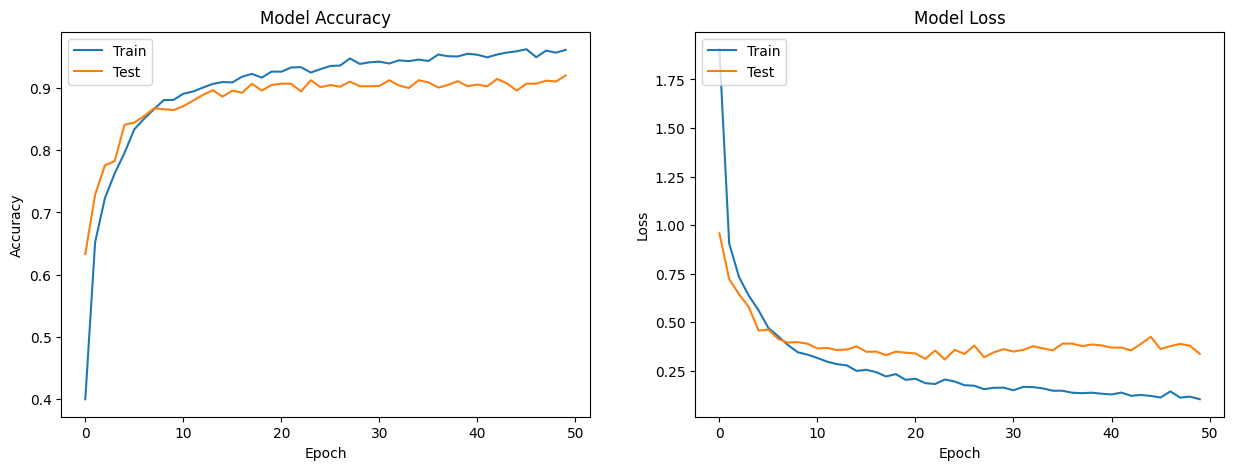

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_title('Model Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend(['Train', 'Test'], loc='upper left')

ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_title('Model Loss')
ax2.set_ylabel('Loss')
ax2.set_xlabel('Epoch')
ax2.legend(['Train', 'Test'], loc='upper left')

plt.show()


45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:

              precision    recall  f1-score   support

           1       0.93      0.97      0.95        40
          10       1.00      1.00      1.00        40
           2       0.97      0.95      0.96        40
           3       0.97      0.95      0.96        40
           4       0.98      1.00      0.99        40
           5       0.97      0.97      0.97        40
           6       1.00      1.00      1.00        40
           7       0.95      0.97      0.96        40
           8       1.00      1.00      1.00        40
           9       1.00      1.00      1.00        40
           a       0.86      0.95      0.90        40
           b       1.00      0.97      0.99        40
           c       0.94      0.85      0.89        40
           d       0.84      0.80      0.82        40
           e       0.97      0.90      0.94        40
           f       0.95      0.97      0.96        40
           g     

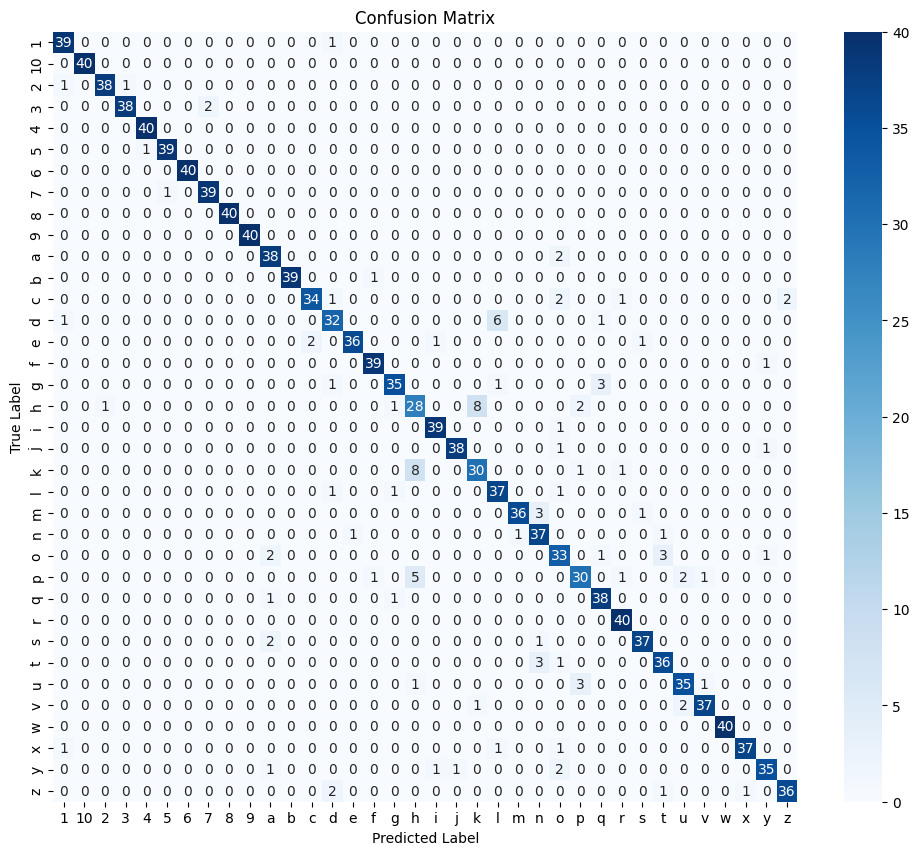

In [12]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

class_names = label_encoder.classes_

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()
